<a href="https://colab.research.google.com/github/NguyenManhCuong1512/AI/blob/main/Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    StratifiedKFold, GridSearchCV
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier  # pip install xgboost

# Dataset dùng xuyên suốt
bc   = load_breast_cancer()   # nhị phân, 569 mẫu, 30 đặc trưng
iris = load_iris()            # 3 lớp,   150 mẫu,  4 đặc trưng
wine = load_wine()            # 3 lớp,   178 mẫu, 13 đặc trưng

X_bc, y_bc     = bc.data,   bc.target
X_iris, y_iris = iris.data, iris.target
X_wine, y_wine = wine.data, wine.target

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42
)

single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, oob_score=True, random_state=42, n_jobs=-1
)
bagging.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=100, oob_score=True, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

for name, model in [("Single Tree", single_tree), ("Bagging", bagging), ("Random Forest", rf)]:
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    oob = f" | OOB: {model.oob_score_:.4f}" if hasattr(model, "oob_score_") else ""
    print(f"AUC — {name:<16}: {auc:.4f}{oob}")

AUC — Single Tree     : 0.9157
AUC — Bagging         : 0.9927 | OOB: 0.9560
AUC — Random Forest   : 0.9937 | OOB: 0.9538


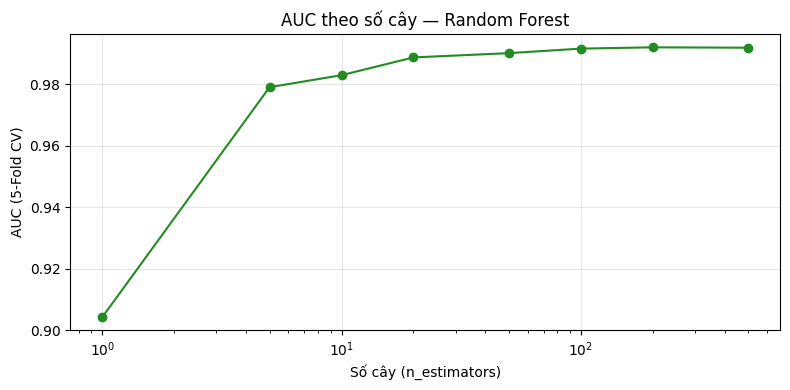

In [14]:
n_trees = [1, 5, 10, 20, 50, 100, 200, 500]
auc_by_n = [
    cross_val_score(
        RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1),
        X_bc, y_bc, cv=5, scoring="roc_auc"
    ).mean()
    for n in n_trees
]

plt.figure(figsize=(8, 4))
plt.semilogx(n_trees, auc_by_n, "o-", color="forestgreen")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("AUC (5-Fold CV)")
plt.title("AUC theo số cây — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# AUC thường ổn định sau ~100 cây

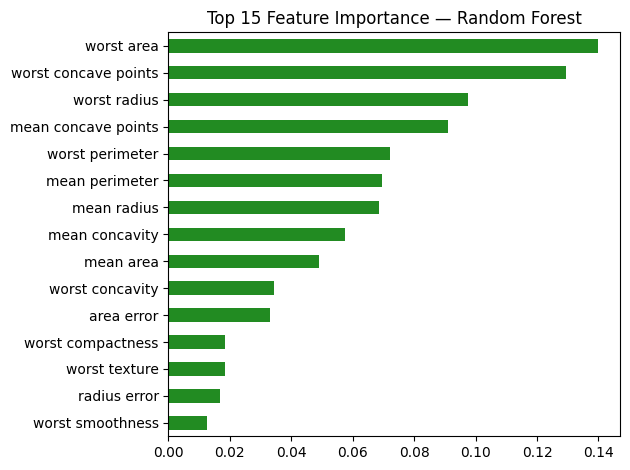

Tham số tốt nhất: {'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}
AUC CV tốt nhất: 0.9907
AUC test set:    0.9924


In [15]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=bc.feature_names).sort_values()
feat_imp.tail(15).plot(kind="barh", color="forestgreen")
plt.title("Top 15 Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

# Tuning
param_grid_rf = {
    "n_estimators":     [100, 200],
    "max_features":     ["sqrt", "log2"],
    "min_samples_leaf": [1, 3, 5]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring="roc_auc", n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print("Tham số tốt nhất:", grid_rf.best_params_)
print(f"AUC CV tốt nhất: {grid_rf.best_score_:.4f}")
print(f"AUC test set:    {roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:, 1]):.4f}")